✅ Dataset Loaded:
    Age MedicalCondition PainLevel  InitialFlexScore  SessionsCompleted  \
0   56            Rehab    Severe                 2                  9   
1   69          Healthy    Severe                 9                 19   
2   46        JointCare  Moderate                 5                 10   
3   32          Healthy    Severe                 7                 16   
4   60          Healthy       NaN                 9                 13   

   FinalFlexScore  
0               3  
1              10  
2               8  
3               9  
4              13  

📊 MODEL PERFORMANCE:
Mean Squared Error (MSE): 5.24
R² Score: 0.79
✅ Model Accuracy: 78.83%


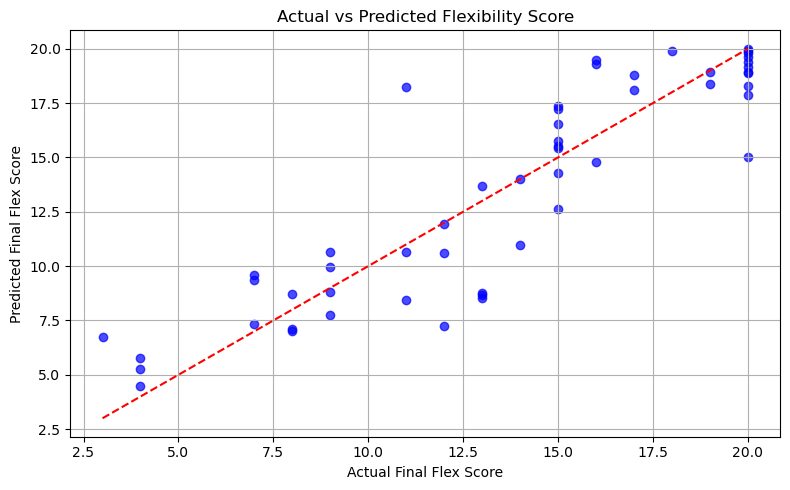


🧪 Example Prediction:
🎯 Predicted Final Flexibility Score: 12.66


In [1]:
# ---------------------------------------------
# 🧠 Flexibility Progress Prediction (Final Version)
# - Uses expanded dataset (400 rows)
# - GridSearchCV for hyperparameter tuning
# - Ensures final score ≥ initial score
# ---------------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# ✅ STEP 1: Load the expanded dataset
df = pd.read_csv("Expanded_Flexibility_Data_400.csv")
print("✅ Dataset Loaded:\n", df.head())

# ✅ STEP 2: Clean data (drop NA)
df.dropna(inplace=True)

# ✅ STEP 3: Encode categorical variables
df_encoded = pd.get_dummies(df, columns=["MedicalCondition", "PainLevel"], drop_first=True)

# ✅ STEP 4: Define features and target
X = df_encoded.drop("FinalFlexScore", axis=1)
y = df_encoded["FinalFlexScore"]

# ✅ STEP 5: Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ✅ STEP 6: Hyperparameter tuning with GridSearchCV
param_grid = {
    'n_estimators': [100, 150, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 4],
}
grid_search = GridSearchCV(RandomForestRegressor(random_state=42), param_grid, cv=3, scoring='r2')
grid_search.fit(X_train, y_train)

# ✅ Use best model from GridSearch
model = grid_search.best_estimator_

# ✅ STEP 7: Evaluate the model
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n📊 MODEL PERFORMANCE:")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R² Score: {r2:.2f}")
print(f"✅ Model Accuracy: {r2 * 100:.2f}%")

# ✅ STEP 8: Plot predictions
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, alpha=0.7, color='blue')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.xlabel("Actual Final Flex Score")
plt.ylabel("Predicted Final Flex Score")
plt.title("Actual vs Predicted Flexibility Score")
plt.grid(True)
plt.tight_layout()
plt.show()

# ✅ STEP 9: Example Prediction
print("\n🧪 Example Prediction:")

# Example input (make sure to match encoded features)
input_values = {
    "Age": 28,
    "InitialFlexScore": 10,
    "SessionsCompleted": 12,
    "MedicalCondition_Healthy": 1,
    "MedicalCondition_JointCare": 0,
    "MedicalCondition_Rehab": 0,
    "PainLevel_None": 0,
    "PainLevel_Moderate": 1,
    "PainLevel_Severe": 0
}

# Initialize zero-filled DataFrame matching training features
sample_input = pd.DataFrame([0]*X.shape[1], index=X.columns).T

# Update input values
for key, value in input_values.items():
    if key in sample_input.columns:
        sample_input[key] = value

# Predict
predicted_score = model.predict(sample_input)[0]

# Ensure no regression in flexibility
initial_score = input_values["InitialFlexScore"]
final_score = max(predicted_score, initial_score)

print(f"🎯 Predicted Final Flexibility Score: {final_score:.2f}")



